# post-mapping analysis

assumes `01_setup_distance_mapping.ipynb` has been run and that `output_case/*_distances.csv` exist

In [1]:
import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.2)

RES_DIR = 'res'
PAIRED_MEASUREMENTS_CSV = os.path.join(RES_DIR, 'paired_measurements.csv')
DCM_METADATA_CSV = os.path.join(RES_DIR, 'dcm_metadata.csv')

# Cases only
OUTDIR = 'output_case'

# Grids for analysis
YGRID = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)
ZGRID = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)

BIN_SIZE_MM = 1.0
RANGE_MM = 3.0
PLOT_3D_SURFACE = True

print('OUTDIR:', OUTDIR)


OUTDIR: output_case


In [2]:
# -------------------------
# Helpers
# -------------------------

def as_str_id(x):
    if pd.isna(x):
        return None
    try:
        if isinstance(x, (int, np.integer)):
            return str(int(x))
        if isinstance(x, (float, np.floating)) and float(x).is_integer():
            return str(int(x))
    except Exception:
        pass
    return str(x).strip()

def load_distances_csv(path):
    df = pd.read_csv(path, header=None, names=['distance','Y','Z'])
    df = df.dropna()
    for c in ['distance','Y','Z']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna()
    return df

def sample_distance_nearest(df, y0, z0):
    d2 = (df['Y'] - y0) ** 2 + (df['Z'] - z0) ** 2
    idx = d2.idxmin()
    return float(df.loc[idx, 'distance'])

def safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.allclose(np.std(x), 0) or np.allclose(np.std(y), 0):
        return np.nan, np.nan
    r, p = stats.pearsonr(x, y)
    return float(r), float(p)

def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3:
        return np.nan, np.nan
    r, p = stats.spearmanr(x, y)
    return float(r), float(p)

def mae(err):
    err = np.asarray(err, dtype=float)
    return float(np.mean(np.abs(err)))

def rmse(err):
    err = np.asarray(err, dtype=float)
    return float(np.sqrt(np.mean(err ** 2)))

def format_float(x, nd=3):
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return 'NA'
    return f'{x:.{nd}f}'


In [3]:
# -------------------------
# Load cohort (manual paired + available distance files)
# -------------------------

df_manual = pd.read_csv(PAIRED_MEASUREMENTS_CSV, dtype={'patient_id': str, 'sl_distance': float})
df_manual['patient_id'] = df_manual['patient_id'].apply(as_str_id)
df_manual = df_manual.rename(columns={'sl_distance': 'manual_sld'}).dropna(subset=['patient_id','manual_sld'])

# Distance files from cases only
paths = sorted(glob.glob(os.path.join(OUTDIR, '*_distances.csv')))
distmap = {}
for p in paths:
    m = re.search(r'([0-9]+)_distances\.csv$', os.path.basename(p))
    if m:
        distmap[m.group(1)] = p

avail_ids = sorted(set(df_manual['patient_id']).intersection(set(distmap.keys())))
if len(avail_ids) == 0:
    raise RuntimeError('No overlapping patient_id between paired_measurements.csv and output_case/*_distances.csv')

df_pat = df_manual[df_manual['patient_id'].isin(avail_ids)].copy().reset_index(drop=True)

print('Manual paired n:', len(df_manual))
print('Distance files found (cases):', len(distmap))
print('Overlapping set n:', len(df_pat))

# Cache per-patient distances
_dfcache = {pid: load_distances_csv(distmap[pid]) for pid in avail_ids}


Manual paired n: 29
Distance files found (cases): 25
Overlapping set n: 25


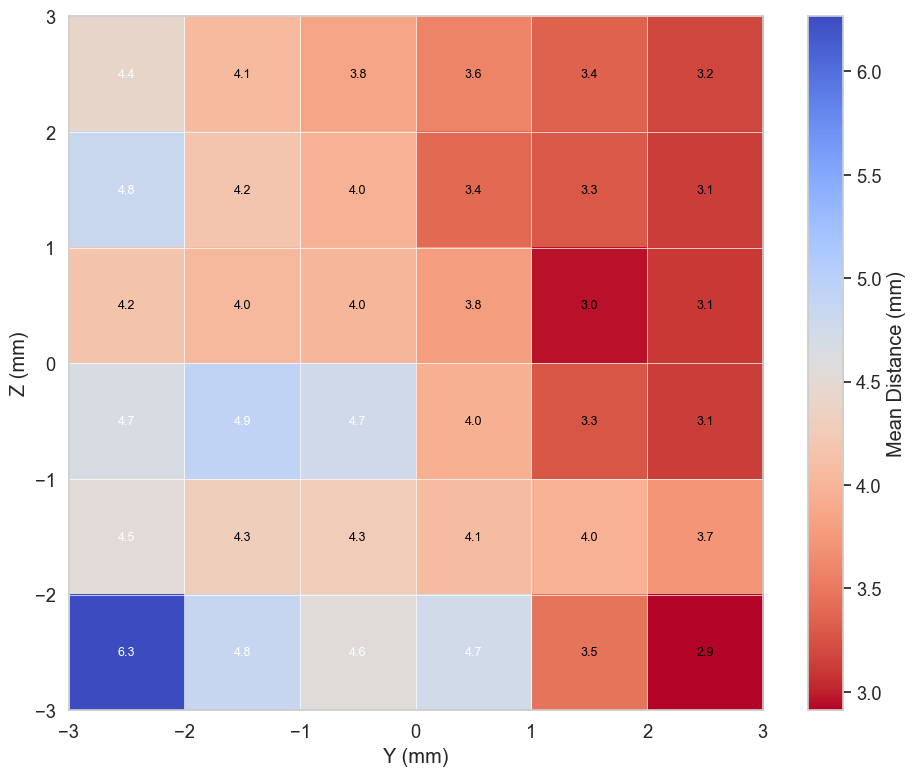

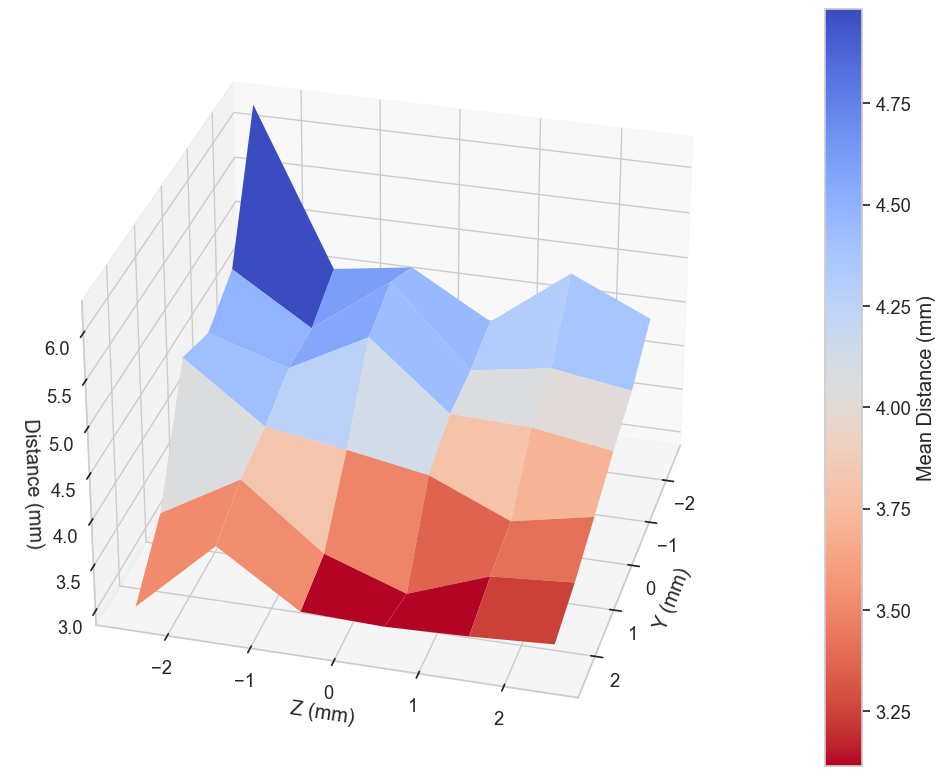

In [4]:
# -------------------------
# Figure: aggregate mean-distance heatmap (Y/Z bins)
# -------------------------

all_dist = []
all_yz = []
for pid in avail_ids:
    df = _dfcache[pid]
    all_dist.append(df['distance'].values)
    all_yz.append(df[['Y','Z']].values)

all_dist = np.concatenate(all_dist)
all_yz = np.vstack(all_yz)

y_edges = np.arange(-RANGE_MM, RANGE_MM + BIN_SIZE_MM, BIN_SIZE_MM)
z_edges = np.arange(-RANGE_MM, RANGE_MM + BIN_SIZE_MM, BIN_SIZE_MM)

heat = np.full((len(z_edges) - 1, len(y_edges) - 1), np.nan)
count = np.zeros_like(heat, dtype=float)

for (y, z), dist in zip(all_yz, all_dist):
    yi = np.digitize(y, y_edges) - 1
    zi = np.digitize(z, z_edges) - 1
    if 0 <= yi < heat.shape[1] and 0 <= zi < heat.shape[0]:
        if np.isnan(heat[zi, yi]):
            heat[zi, yi] = dist
        else:
            heat[zi, yi] += dist
        count[zi, yi] += 1

with np.errstate(invalid='ignore', divide='ignore'):
    heat = heat / count
    heat[count == 0] = np.nan

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    heat, origin='lower', cmap='coolwarm_r',
    extent=[y_edges[0], y_edges[-1], z_edges[0], z_edges[-1]],
    aspect='equal'
)
ax.set_xticks(y_edges)
ax.set_yticks(z_edges)
ax.grid(True, color='white', linewidth=0.5)

for i in range(len(z_edges) - 1):
    for j in range(len(y_edges) - 1):
        val = heat[i, j]
        if not np.isnan(val):
            yc = (y_edges[j] + y_edges[j + 1]) / 2
            zc = (z_edges[i] + z_edges[i + 1]) / 2
            color = 'black' if val < 0.7 * np.nanmax(heat) else 'white'
            ax.text(yc, zc, f'{val:.1f}', ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im, ax=ax, label='Mean Distance (mm)')
ax.set_xlabel('Y (mm)')
ax.set_ylabel('Z (mm)')
plt.tight_layout()
plt.show()

if PLOT_3D_SURFACE:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    Y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    Z_centers = (z_edges[:-1] + z_edges[1:]) / 2
    Y_grid, Z_grid = np.meshgrid(Y_centers, Z_centers)

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(Y_grid, Z_grid, heat, cmap='coolwarm_r', edgecolor='none')
    ax.view_init(elev=30, azim=15)
    fig.colorbar(surf, ax=ax, label='Mean Distance (mm)')
    ax.set_xlabel('Y (mm)')
    ax.set_ylabel('Z (mm)')
    ax.set_zlabel('Distance (mm)')
    plt.tight_layout()
    plt.show()


---- Grid correlation peak ----
Peak Y,Z: -1.0 3.0 | Pearson r: 0.507 | p: 0.010 | n: 25


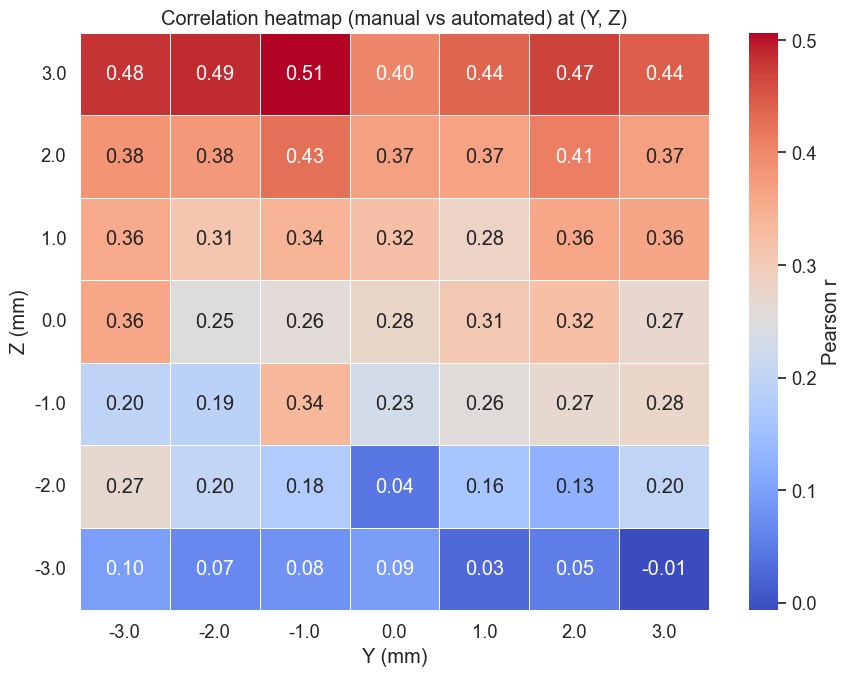

Top grid locations by Pearson r (first 10):
   Y   Z        r        p  n
-1.0 3.0 0.506616 0.009756 25
-2.0 3.0 0.486917 0.013569 25
-3.0 3.0 0.480570 0.015032 25
 2.0 3.0 0.469599 0.017864 25
 3.0 3.0 0.444054 0.026168 25
 1.0 3.0 0.436437 0.029171 25
-1.0 2.0 0.425238 0.034081 25
 2.0 2.0 0.409531 0.042055 25
 0.0 3.0 0.401956 0.046393 25
-3.0 2.0 0.384459 0.057755 25
---- Manual vs automated at peak coordinate ----
Peak coordinate used Y,Z: -1.0 3.0
Pearson r: 0.507 p: 0.010
Spearman rho: 0.518 p: 0.008
Linear fit: auto = a*manual + b | a= 0.555 b= 2.635
MAE |auto-manual| (mm): 1.489
RMSE (mm): 1.833
Mean bias auto-manual (mm): 1.173
SD error (mm): 1.438


,patient_id,manual_sld,auto_sld_at_peak,error_auto_minus_manual,abs_error
0,00302086,1.6,5.695312,4.095313,4.095313
1,00083756,3.3,6.638672,3.338672,3.338672
2,00302075,1.7,4.861765,3.161765,3.161765
3,00328931,2.4,5.066060,2.666060,2.666060
4,00302092,3.3,5.800000,2.500000,2.500000
5,00302081,4.1,6.424904,2.324904,2.324904
6,00302094,4.4,6.600000,2.200000,2.200000
7,00302077,3.1,5.034722,1.934722,1.934722
8,00302073,1.4,3.273792,1.873792,1.873792
9,00302079,6.1,4.400000,-1.700000,1.700000


In [5]:
# -------------------------
# Figure: correlation heatmap (manual radiograph vs CT at fixed Y/Z)
# + identify global peak + save tables
# -------------------------

corrmat = np.full((len(ZGRID), len(YGRID)), np.nan, dtype=float)
pmat = np.full((len(ZGRID), len(YGRID)), np.nan, dtype=float)
nmat = np.zeros((len(ZGRID), len(YGRID)), dtype=int)

for i, z0 in enumerate(ZGRID):
    for j, y0 in enumerate(YGRID):
        autovals = []
        manvals = []
        for _, row in df_pat.iterrows():
            pid = row['patient_id']
            man = float(row['manual_sld'])
            df = _dfcache.get(pid)
            if df is None or len(df) == 0:
                continue
            auto = sample_distance_nearest(df, y0, z0)
            autovals.append(auto)
            manvals.append(man)
        nmat[i, j] = len(manvals)
        r, p = safe_pearson(manvals, autovals)
        corrmat[i, j] = r
        pmat[i, j] = p

flat = corrmat.flatten()
valid = np.where(~np.isnan(flat))[0]
if len(valid) == 0:
    raise RuntimeError('Correlation matrix is all NaN')
peak_flat = valid[np.argmax(flat[valid])]
peaki, peakj = np.unravel_index(peak_flat, corrmat.shape)

ypeak = float(YGRID[peakj])
zpeak = float(ZGRID[peaki])
rpeak = float(corrmat[peaki, peakj])
ppeak = float(pmat[peaki, peakj])
npeak = int(nmat[peaki, peakj])

print('---- Grid correlation peak ----')
print('Peak Y,Z:', ypeak, zpeak, '| Pearson r:', format_float(rpeak), '| p:', format_float(ppeak), '| n:', npeak)

# Heatmap plot
plt.figure(figsize=(9, 7))
ax = sns.heatmap(
    np.flipud(corrmat),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    xticklabels=[f'{y:.1f}' for y in YGRID],
    yticklabels=[f'{z:.1f}' for z in ZGRID[::-1]],
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Pearson r'},
)
ax.set_xlabel('Y (mm)')
ax.set_ylabel('Z (mm)')
ax.set_title('Correlation heatmap (manual vs automated) at (Y, Z)')
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Rank grid locations
rank_rows = []
for i, z0 in enumerate(ZGRID):
    for j, y0 in enumerate(YGRID):
        rank_rows.append({'Y': float(y0), 'Z': float(z0), 'r': float(corrmat[i, j]), 'p': float(pmat[i, j]), 'n': int(nmat[i, j])})
rank_df = pd.DataFrame(rank_rows).sort_values(['r','n'], ascending=[False, False]).reset_index(drop=True)
print('Top grid locations by Pearson r (first 10):')
print(rank_df.head(10).to_string(index=False))

# Patient-level automated value at peak
auto_at_peak = []
for _, row in df_pat.iterrows():
    pid = row['patient_id']
    df = _dfcache[pid]
    auto_at_peak.append(sample_distance_nearest(df, ypeak, zpeak))

df_pat = df_pat.copy()
df_pat['auto_sld_at_peak'] = auto_at_peak

err = (df_pat['auto_sld_at_peak'].values.astype(float) - df_pat['manual_sld'].values.astype(float))

rp, pp = safe_pearson(df_pat['manual_sld'].values, df_pat['auto_sld_at_peak'].values)
rs, ps = safe_spearman(df_pat['manual_sld'].values, df_pat['auto_sld_at_peak'].values)

a, b = np.polyfit(df_pat['manual_sld'].values.astype(float), df_pat['auto_sld_at_peak'].values.astype(float), 1)

print('---- Manual vs automated at peak coordinate ----')
print('Peak coordinate used Y,Z:', ypeak, zpeak)
print('Pearson r:', format_float(rp), 'p:', format_float(pp))
print('Spearman rho:', format_float(rs), 'p:', format_float(ps))
print('Linear fit: auto = a*manual + b | a=', format_float(a), 'b=', format_float(b))
print('MAE |auto-manual| (mm):', format_float(mae(err)))
print('RMSE (mm):', format_float(rmse(err)))
print('Mean bias auto-manual (mm):', format_float(float(np.mean(err))))
print('SD error (mm):', format_float(float(np.std(err, ddof=1))))

out_tbl = df_pat[['patient_id','manual_sld','auto_sld_at_peak']].copy()
out_tbl['error_auto_minus_manual'] = out_tbl['auto_sld_at_peak'] - out_tbl['manual_sld']
out_tbl['abs_error'] = np.abs(out_tbl['error_auto_minus_manual'])
out_tbl = out_tbl.sort_values('abs_error', ascending=False).reset_index(drop=True)

out_tbl.head(10)


Median |auto-manual| at mapped location (mm): 0.105
Mean   |auto-manual| at mapped location (mm): 0.550
Mean mapped Y: -0.039 | Mean mapped Z: -0.320


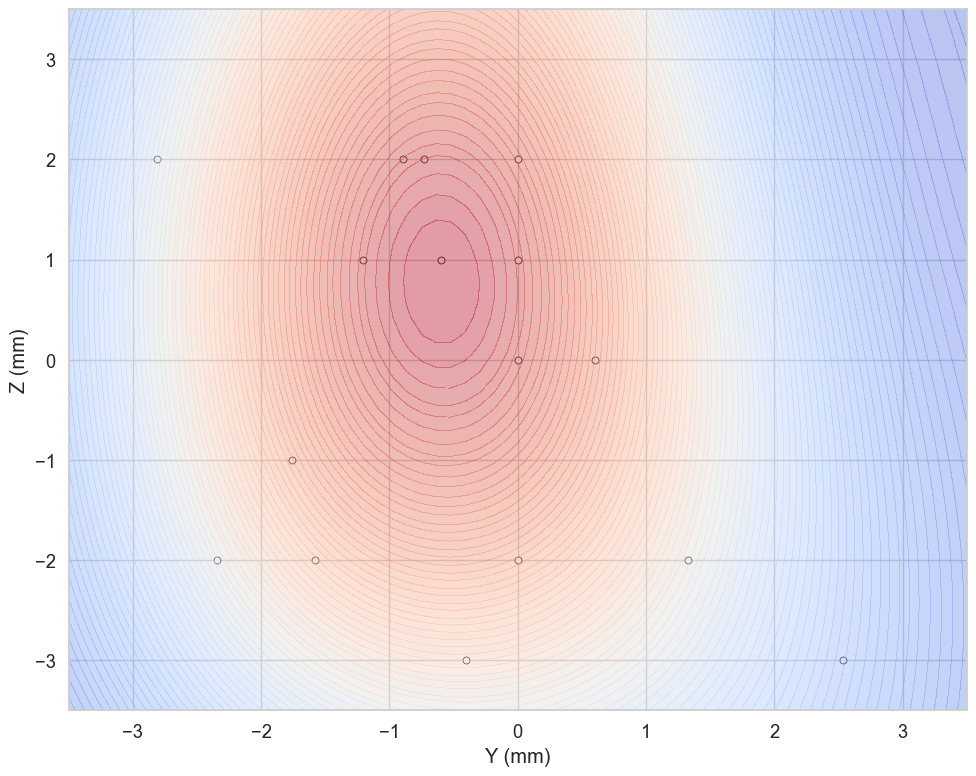

In [6]:
# -------------------------
# Patient-specific mapping: where does the radiograph SLD "land" on the CT map?
# (closest match to manual; ties resolved by closest-to-center in YZ)
# -------------------------

mapped_rows = []
for _, row in df_pat.iterrows():
    pid = row['patient_id']
    manual = float(row['manual_sld'])
    df = _dfcache[pid]

    dif = np.abs(df['distance'].values - manual)
    mind = np.min(dif)
    sub = df.loc[dif == mind, ['Y','Z','distance']].copy()
    if len(sub) == 0:
        continue

    yz = sub[['Y','Z']].values
    d0 = np.sqrt((yz[:,0] ** 2) + (yz[:,1] ** 2))
    k = int(np.argmin(d0))

    mapped_rows.append({
        'patient_id': pid,
        'manual_sld': manual,
        'mapped_Y': float(sub.iloc[k]['Y']),
        'mapped_Z': float(sub.iloc[k]['Z']),
        'mapped_auto': float(sub.iloc[k]['distance']),
        'mapped_absdiff': float(abs(float(sub.iloc[k]['distance']) - manual)),
    })

df_map = pd.DataFrame(mapped_rows)

if len(df_map):
    print('Median |auto-manual| at mapped location (mm):', format_float(df_map['mapped_absdiff'].median()))
    print('Mean   |auto-manual| at mapped location (mm):', format_float(df_map['mapped_absdiff'].mean()))
    print('Mean mapped Y:', format_float(df_map['mapped_Y'].mean()), '| Mean mapped Z:', format_float(df_map['mapped_Z'].mean()))

plt.figure(figsize=(10, 8))
plt.scatter(df_map['mapped_Y'], df_map['mapped_Z'], color='white', s=25, edgecolor='black', linewidth=0.6, alpha=0.9)
sns.kdeplot(x=df_map['mapped_Y'], y=df_map['mapped_Z'], cmap='coolwarm', fill=True, thresh=0.05, levels=100, alpha=0.4)
plt.xlim(-3.5, 3.5)
plt.ylim(-3.5, 3.5)
plt.xlabel('Y (mm)')
plt.ylabel('Z (mm)')
plt.tight_layout()
plt.show()


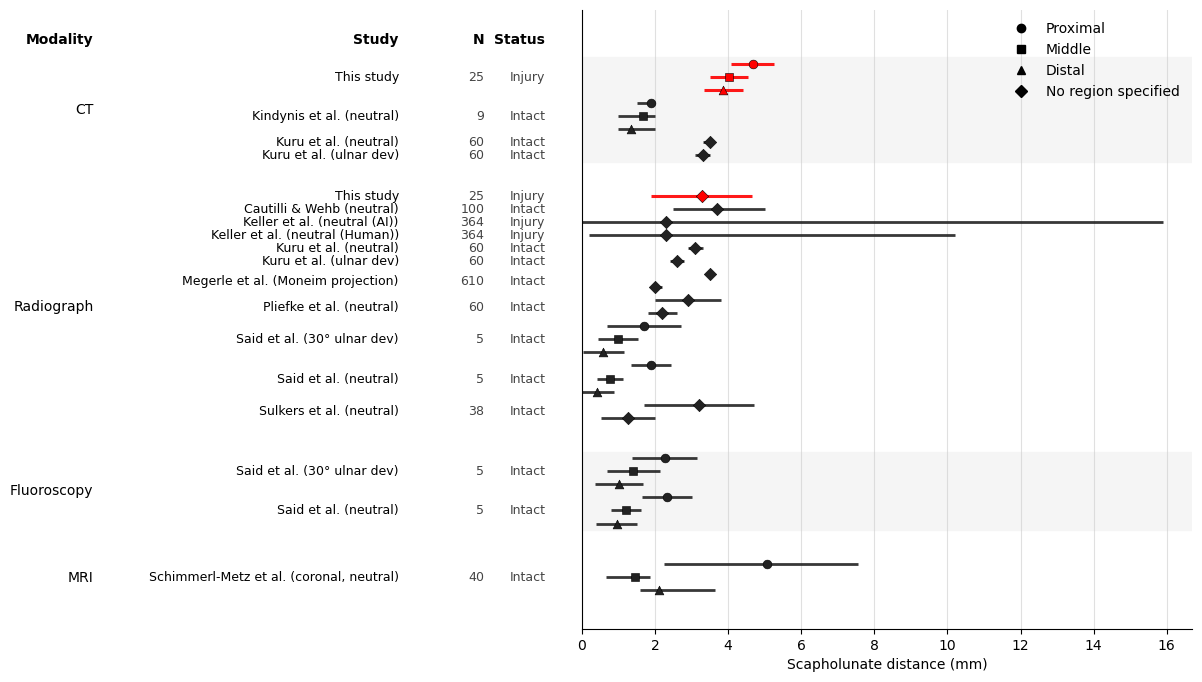

In [1]:
# --- Forest plot: Table 1 + this study (wider + bold modality separators + spaced columns) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# -----------------------------
# 0) Style / constants
# -----------------------------
COLOR_THIS = "#FF0000"   # true red
COLOR_LIT  = "#222222"
LW_RANGE   = 2.0
LW_CI      = 2.2

NO_REGION = "no_region"  # categorical-safe placeholder for "no region specified"

MARKER_BY_REGION = {
    "proximal": "o",
    "middle": "s",
    "distal": "^",
    NO_REGION: "D",
}

REG_ORDER = ["proximal", "middle", "distal", NO_REGION]
MODALITY_ORDER = ["CT", "Radiograph", "Fluoroscopy", "MRI"]

# Wider, more spaced left-side columns (axis-x coords, y in data coords)
X_MODAL  = -0.8
X_STUDY  = -0.30
X_N      = -0.16
X_STATUS = -0.06

# Vertical dividers between columns
X_DIV_MS = -0.62
X_DIV_SN = -0.36
X_DIV_NS = -0.14

SHADE_COLORS = ("#F5F5F5", "#FFFFFF")

# bold modality separator rule
MOD_RULE_COLOR = "#040404"
MOD_RULE_LW = 1.6

# -----------------------------
# 1) Build plotting table
# -----------------------------
rows = []

def normalize_status(status):
    s = (status or "").strip().lower()
    if "intact" in s:
        return "Intact"
    return "Injury"

def add_row(
    study, modality, condition, status, n,
    region, mean,
    sd=None, lo=None, hi=None,
    source="literature",
    kind="sd",
):
    region_norm = NO_REGION if region is None else region
    rows.append({
        "source": source,                 # "this" or "literature"
        "study": study,
        "modality": modality,
        "condition": condition,
        "status": normalize_status(status),
        "n": int(n) if n is not None else np.nan,
        "region": region_norm,
        "mean": float(mean),
        "sd": None if sd is None else float(sd),
        "lo": None if lo is None else float(lo),
        "hi": None if hi is None else float(hi),
        "kind": kind,                     # "this_ci95" | "sd" | "range" | "ci"
    })

# ---- This study ----
add_row("This study", "Radiograph", "neutral", "SLIL lesion or tear", 25, None, 3.28, sd=1.38, lo=1.40, hi=6.50, source="this", kind="sd")
add_row("This study", "CT",         "neutral", "SLIL lesion or tear", 25, "proximal", 4.67, sd=1.48, source="this", kind="this_ci95")
add_row("This study", "CT",         "neutral", "SLIL lesion or tear", 25, "middle",   4.03, sd=1.34, source="this", kind="this_ci95")
add_row("This study", "CT",         "neutral", "SLIL lesion or tear", 25, "distal",   3.87, sd=1.37, source="this", kind="this_ci95")

# ---- Said et al. ----
add_row("Said et al.", "Radiograph",   "neutral",        "Intact", 5, "proximal", 1.90, sd=0.55, source="literature", kind="sd")
add_row("Said et al.", "Radiograph",   "neutral",        "Intact", 5, "middle",   0.77, sd=0.35, source="literature", kind="sd")
add_row("Said et al.", "Radiograph",   "neutral",        "Intact", 5, "distal",   0.40, sd=0.48, source="literature", kind="sd")
add_row("Said et al.", "Radiograph",   "30° ulnar dev",  "Intact", 5, "proximal", 1.70, sd=1.00, source="literature", kind="sd")
add_row("Said et al.", "Radiograph",   "30° ulnar dev",  "Intact", 5, "middle",   0.99, sd=0.54, source="literature", kind="sd")
add_row("Said et al.", "Radiograph",   "30° ulnar dev",  "Intact", 5, "distal",   0.59, sd=0.57, source="literature", kind="sd")
add_row("Said et al.", "Fluoroscopy",  "neutral",        "Intact", 5, "proximal", 2.33, sd=0.68, source="literature", kind="sd")
add_row("Said et al.", "Fluoroscopy",  "neutral",        "Intact", 5, "middle",   1.21, sd=0.41, source="literature", kind="sd")
add_row("Said et al.", "Fluoroscopy",  "neutral",        "Intact", 5, "distal",   0.95, sd=0.56, source="literature", kind="sd")
add_row("Said et al.", "Fluoroscopy",  "30° ulnar dev",  "Intact", 5, "proximal", 2.26, sd=0.88, source="literature", kind="sd")
add_row("Said et al.", "Fluoroscopy",  "30° ulnar dev",  "Intact", 5, "middle",   1.41, sd=0.73, source="literature", kind="sd")
add_row("Said et al.", "Fluoroscopy",  "30° ulnar dev",  "Intact", 5, "distal",   1.01, sd=0.66, source="literature", kind="sd")

# ---- Cautilli and Wehb. ----
add_row("Cautilli & Wehb", "Radiograph", "neutral", "Intact", 100, None, 3.7, sd=0.6, lo=2.5, hi=5.0, source="literature", kind="range")

# ---- Kindynis et al. ----
add_row("Kindynis et al.", "CT", "neutral", "Intact", 9, "proximal", 1.88, lo=1.5, hi=2.0, source="literature", kind="range")
add_row("Kindynis et al.", "CT", "neutral", "Intact", 9, "middle",   1.66, lo=1.0, hi=2.0, source="literature", kind="range")
add_row("Kindynis et al.", "CT", "neutral", "Intact", 9, "distal",   1.33, lo=1.0, hi=2.0, source="literature", kind="range")

# ---- Megerle et al. (label spelled Moneim per updated table request) ----
add_row("Megerle et al.", "Radiograph", "Moneim projection", "SLIL lesion or tear", 239, None, 3.5, lo=3.4, hi=3.6, source="literature", kind="ci")
add_row("Megerle et al.", "Radiograph", "Moneim projection", "Intact",             610, None, 2.0, lo=1.9, hi=2.2, source="literature", kind="ci")

# ---- Pliefke et al. ----
add_row("Pliefke et al.", "Radiograph", "neutral", "SLIL lesion or tear", 42, None, 2.9, sd=0.9, source="literature", kind="sd")
add_row("Pliefke et al.", "Radiograph", "neutral", "Intact",              60, None, 2.2, sd=0.4, source="literature", kind="sd")

# ---- Schimmerl-Metz et al. ----
add_row("Schimmerl-Metz et al.", "MRI", "coronal, neutral", "Intact", 40, "proximal", 5.05, lo=2.25, hi=7.55, source="literature", kind="range")
add_row("Schimmerl-Metz et al.", "MRI", "coronal, neutral", "Intact", 40, "middle",   1.45, lo=0.65, hi=1.85, source="literature", kind="range")
add_row("Schimmerl-Metz et al.", "MRI", "coronal, neutral", "Intact", 40, "distal",   2.10, lo=1.60, hi=3.65, source="literature", kind="range")

# ---- Keller et al. (keep both Human and AI) ----
add_row("Keller et al.", "Radiograph", "neutral (Human)", "SLIL lesion or tear", 364, None, 2.3, lo=0.2, hi=10.2, source="literature", kind="range")
add_row("Keller et al.", "Radiograph", "neutral (AI)",    "SLIL lesion or tear", 364, None, 2.3, lo=0.0, hi=15.9, source="literature", kind="range")

# ---- Sulkers et al. (split N per updated screenshot) ----
add_row("Sulkers et al.", "Radiograph", "neutral",    "SLIL lesion or tear", 38, None, 3.21, sd=1.51, source="literature", kind="sd")
add_row("Sulkers et al.", "Radiograph", "neutral", "Intact",              24, None, 1.25, sd=0.74, source="literature", kind="sd")

# ---- Kuru et al. ----
add_row("Kuru et al.", "Radiograph", "neutral",   "Intact", 60, None, 3.1, lo=2.9, hi=3.3, source="literature", kind="ci")
add_row("Kuru et al.", "Radiograph", "ulnar dev", "Intact", 60, None, 2.6, lo=2.4, hi=2.8, source="literature", kind="ci")
add_row("Kuru et al.", "CT",         "neutral",   "Intact", 60, None, 3.5, lo=3.3, hi=3.6, source="literature", kind="ci")
add_row("Kuru et al.", "CT",         "ulnar dev", "Intact", 60, None, 3.3, lo=3.1, hi=3.5, source="literature", kind="ci")

df = pd.DataFrame(rows)

# Safety: ensure finite means (prevents "posx and posy should be finite values")
df = df[np.isfinite(df["mean"].to_numpy(dtype=float))].copy()

df["region"] = pd.Categorical(df["region"], categories=REG_ORDER, ordered=True)
df["modality"] = pd.Categorical(df["modality"], categories=MODALITY_ORDER, ordered=True)
df["source_rank"] = df["source"].map({"this": 0, "literature": 1}).fillna(9).astype(int)

# -----------------------------
# 2) Derive plotting intervals
# -----------------------------
def ci95_from_sd(mean, sd, n):
    if sd is None or not np.isfinite(sd) or n is None or not np.isfinite(n) or n <= 1:
        return None, None
    half = 1.96 * sd / np.sqrt(n)
    return mean - half, mean + half

plot_lo, plot_hi = [], []
for r in df.itertuples(index=False):
    lo = hi = r.mean

    if r.kind == "this_ci95":
        tlo, thi = ci95_from_sd(r.mean, r.sd, r.n)
        if (tlo is not None) and (thi is not None):
            lo, hi = tlo, thi
    elif r.kind == "sd":
        if (r.sd is not None) and np.isfinite(r.sd):
            lo, hi = r.mean - r.sd, r.mean + r.sd
        elif (r.lo is not None) and (r.hi is not None) and np.isfinite(r.lo) and np.isfinite(r.hi):
            lo, hi = r.lo, r.hi
    elif r.kind in ("range", "ci"):
        if (r.lo is not None) and (r.hi is not None) and np.isfinite(r.lo) and np.isfinite(r.hi):
            lo, hi = r.lo, r.hi

    if not np.isfinite(lo): lo = r.mean
    if not np.isfinite(hi): hi = r.mean

    plot_lo.append(float(lo))
    plot_hi.append(float(hi))

df["plot_lo"] = plot_lo
df["plot_hi"] = plot_hi

# -----------------------------
# 3) Labels + ordering + y positions
# -----------------------------
def study_display(study, condition):
    if study == "This study":
        return "This study"
    cond = (condition or "").strip()
    return f"{study} ({cond})" if cond else study

df["study_label"] = [study_display(s, c) for s, c in zip(df["study"], df["condition"])]

df = df.sort_values(["modality", "source_rank", "study_label", "region"], kind="mergesort").reset_index(drop=True)

# Assign y with gaps between modalities
ys = []
y = 0.0
gap_between_modalities = 2.1
last_mod = None
for r in df.itertuples(index=False):
    if (last_mod is not None) and (r.modality != last_mod):
        y += gap_between_modalities
    ys.append(y)
    y += 1.0
    last_mod = r.modality

df["y"] = ys
df["y"] = df["y"].max() - df["y"]

# Group centers (explicit observed= to silence FutureWarning)
centers = (
    df.groupby(["modality", "study_label"], sort=False, observed=False)["y"]
      .mean()
      .reset_index()
      .rename(columns={"y": "y_center"})
)

block_meta = (
    df.groupby(["modality", "study_label"], sort=False, observed=False)
      .agg(n=("n", "max"), status=("status", "max"))
      .reset_index()
)

centers = centers.merge(block_meta, on=["modality", "study_label"], how="left")

mod_stats = (
    df.groupby("modality", sort=False, observed=False)["y"]
      .agg(ymin="min", ymax="max", ymid="mean")
      .reset_index()
)

# -----------------------------
# 4) Plot
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Wider figure
fig, ax = plt.subplots(figsize=(16.5, 7.2))

# x-limits (before rules)
finite_lo = df["plot_lo"].to_numpy(dtype=float)
finite_hi = df["plot_hi"].to_numpy(dtype=float)
finite_lo = finite_lo[np.isfinite(finite_lo)]
finite_hi = finite_hi[np.isfinite(finite_hi)]
xmin = float(np.min(finite_lo)) if finite_lo.size else 0.0
xmax = float(np.max(finite_hi)) if finite_hi.size else 1.0
pad = 0.8
ax.set_xlim(max(0, xmin - pad), xmax + pad)

# Background shading by modality block
for i, m in enumerate(MODALITY_ORDER):
    sub = mod_stats[mod_stats["modality"] == m]
    if sub.empty:
        continue
    ymin = float(sub["ymin"].iloc[0]) - 0.5
    ymax = float(sub["ymax"].iloc[0]) + 0.5
    ax.axhspan(ymin, ymax, color=SHADE_COLORS[i % 2], zorder=0)

# Bold horizontal rules between modality blocks
# Use the boundary between consecutive modality blocks (in y-data coords)
# mod_present = [m for m in MODALITY_ORDER if not mod_stats[mod_stats["modality"] == m].empty]
# for i in range(len(mod_present) - 1):
#     m_next = mod_present[i + 1]
#     # boundary is just above the next block's ymax (because y is inverted)
#     sub_next = mod_stats[mod_stats["modality"] == m_next]
#     y_rule = float(sub_next["ymax"].iloc[0]) + 0.5
#     ax.hlines(y_rule, ax.get_xlim()[0], ax.get_xlim()[1],
#               color=MOD_RULE_COLOR, linewidth=MOD_RULE_LW, zorder=1)

# Intervals + points
for r in df.itertuples(index=False):
    if not np.isfinite(r.y) or not np.isfinite(r.mean):
        continue

    color = COLOR_THIS if r.source == "this" else COLOR_LIT
    marker = MARKER_BY_REGION.get(r.region, "D")

    if np.isfinite(r.plot_lo) and np.isfinite(r.plot_hi) and (r.plot_hi != r.plot_lo):
        lw = LW_CI if r.source == "this" else LW_RANGE
        ax.hlines(y=r.y, xmin=r.plot_lo, xmax=r.plot_hi, color=color, linewidth=lw, alpha=0.9, zorder=2)

    ax.scatter(r.mean, r.y, s=40, marker=marker, color=color, edgecolors="k", linewidths=0.4, zorder=3)

# -----------------------------
# 5) Left columns + dividers (no y ticks)
# -----------------------------
ax.set_yticks([])
ax.tick_params(axis="y", left=False)

ymin_all = float(df["y"].min()) - 0.8
ymax_all = float(df["y"].max()) + 0.8
y_header = float(df["y"].max()) + 1.35

# Column headers
ax.text(X_MODAL,  y_header, "Modality", transform=ax.get_yaxis_transform(), ha="right", va="bottom", fontsize=10, fontweight="bold")
ax.text(X_STUDY,  y_header, "Study",    transform=ax.get_yaxis_transform(), ha="right", va="bottom", fontsize=10, fontweight="bold")
ax.text(X_N,      y_header, "N",        transform=ax.get_yaxis_transform(), ha="right", va="bottom", fontsize=10, fontweight="bold")
ax.text(X_STATUS, y_header, "Status",   transform=ax.get_yaxis_transform(), ha="right", va="bottom", fontsize=10, fontweight="bold")

# Vertical dividers
for xv in (X_DIV_MS, X_DIV_SN, X_DIV_NS):
    ax.plot([xv, xv], [ymin_all, y_header + 0.65],
            transform=ax.get_yaxis_transform(),
            color="#808080", linewidth=1.2, zorder=4)

# Modality labels at block midpoints
for r in mod_stats.itertuples(index=False):
    if not np.isfinite(r.ymid):
        continue
    ax.text(X_MODAL, float(r.ymid), str(r.modality),
            transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=10)

# Study/N/Status labels centered per (modality, study_label) block
for r in centers.itertuples(index=False):
    if not np.isfinite(r.y_center):
        continue
    ax.text(X_STUDY, float(r.y_center), str(r.study_label),
            transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=9)
    n_txt = "" if (r.n is None or (isinstance(r.n, float) and np.isnan(r.n))) else str(int(r.n))
    ax.text(X_N, float(r.y_center), n_txt,
            transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=9, color="#444444")
    ax.text(X_STATUS, float(r.y_center), str(r.status),
            transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=9, color="#444444")

# -----------------------------
# 6) Legend: regions only
# -----------------------------
region_handles = [
    mlines.Line2D([], [], color="black", marker="o", linestyle="None", markersize=6, label="Proximal"),
    mlines.Line2D([], [], color="black", marker="s", linestyle="None", markersize=6, label="Middle"),
    mlines.Line2D([], [], color="black", marker="^", linestyle="None", markersize=6, label="Distal"),
    mlines.Line2D([], [], color="black", marker="D", linestyle="None", markersize=6, label="No region specified"),
]
ax.legend(handles=region_handles, frameon=False, loc="upper right")

# -----------------------------
# 7) Axes + layout
# -----------------------------
ax.set_xlabel("Scapholunate distance (mm)")
ax.grid(axis="x", color="#D0D0D0", linewidth=0.8, alpha=0.65)

# Give the table area room while keeping the plot area wide (because the overall figure is wider now)
fig.subplots_adjust(left=0.62, right=0.99, top=0.96, bottom=0.10)

plt.show()
fig.savefig("figure3.png", dpi=600, bbox_inches="tight", facecolor="white")


Generate final numbers for manuscript (INSERT)